# CIC6314 — Smart Product Recommendation System
**Member 3 — ML module**
Dataset: UCI Online Retail | Models: RF classifiers (category prediction) + ALS (product scoring)


## 1. Load Data


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

df_raw = pd.read_excel('data/online+retail/Online Retail.xlsx')
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. EDA
Explore the dataset before doing anything to it.


In [49]:
# basic info
print(df_raw.dtypes)
print()
print(df_raw.describe())


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  

In [50]:
# check missing values
print('Missing values:')
print(df_raw.isnull().sum())
# CustomerID has a lot of nulls - those are guest checkouts


Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [51]:
# how many unique customers and products
print('Unique customers:', df_raw['CustomerID'].nunique())
print('Unique products:', df_raw['StockCode'].nunique())
print('Unique countries:', df_raw['Country'].nunique())
print('Date range:', df_raw['InvoiceDate'].min(), 'to', df_raw['InvoiceDate'].max())


Unique customers: 4372
Unique products: 4070
Unique countries: 38
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [52]:
# check for cancelled orders - invoices starting with C
cancelled = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')]
print('Cancelled rows:', len(cancelled))
print('Normal rows:', len(df_raw) - len(cancelled))


Cancelled rows: 9288
Normal rows: 532621


In [53]:
# quantity distribution - are there negatives?
print('Quantity stats:')
print(df_raw['Quantity'].describe())
print('Negative quantity rows:', (df_raw['Quantity'] < 0).sum())
print('Zero price rows:', (df_raw['UnitPrice'] == 0).sum())


Quantity stats:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64
Negative quantity rows: 10624
Zero price rows: 2515


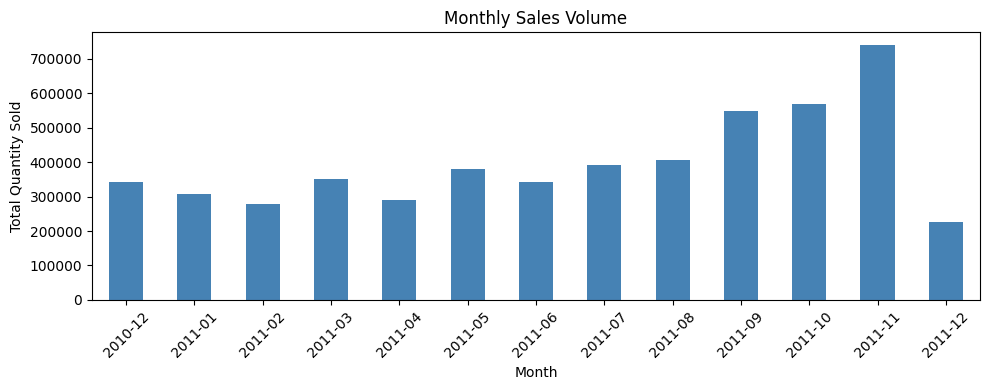

In [54]:
# sales over time
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['Month'] = df_raw['InvoiceDate'].dt.to_period('M')
monthly = df_raw.groupby('Month')['Quantity'].sum()

plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='steelblue')
plt.title('Monthly Sales Volume')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:
# top 10 most purchased products
top_products = df_raw.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print('Top 10 products:')
print(top_products)


Top 10 products:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64


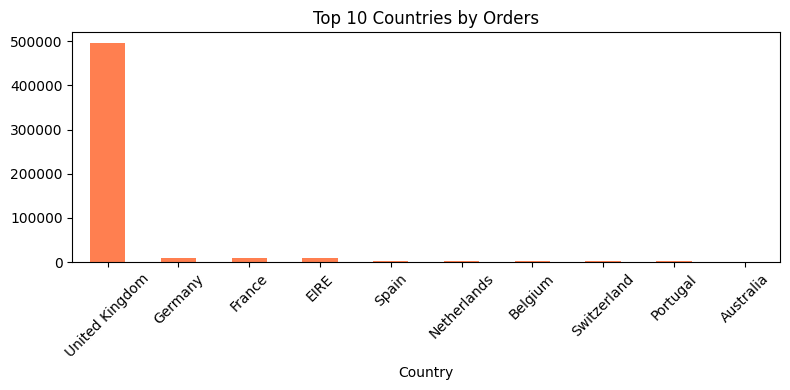

In [56]:
# top 10 countries by number of orders
top_countries = df_raw['Country'].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_countries.plot(kind='bar', color='coral')
plt.title('Top 10 Countries by Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Products per customer:
count    4372.000000
mean       61.211116
std        85.425119
min         1.000000
25%        15.000000
50%        35.000000
75%        77.000000
max      1794.000000
Name: StockCode, dtype: float64


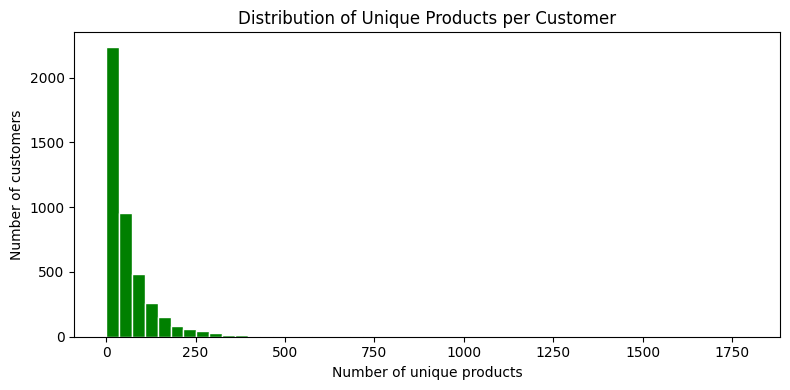

In [57]:
# how many products does the average customer buy?
items_per_customer = df_raw.groupby('CustomerID')['StockCode'].nunique()
print('Products per customer:')
print(items_per_customer.describe())

plt.figure(figsize=(8, 4))
plt.hist(items_per_customer, bins=50, color='green', edgecolor='white')
plt.title('Distribution of Unique Products per Customer')
plt.xlabel('Number of unique products')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()


## 3. Data Cleaning
Remove bad rows found in EDA.


In [58]:
df = df_raw.copy()

before = len(df)

# drop guest checkouts (no CustomerID)
df = df[df['CustomerID'].notna()]
print('After removing nulls:', len(df), '(removed', before - len(df), 'rows)')

# drop cancellations
step = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print('After removing cancellations:', len(df), '(removed', step - len(df), 'rows)')

# drop returns and adjustments
step = len(df)
df = df[df['Quantity'] > 0]
print('After removing negative quantity:', len(df), '(removed', step - len(df), 'rows)')

# drop zero price rows
step = len(df)
df = df[df['UnitPrice'] > 0]
print('After removing zero price:', len(df), '(removed', step - len(df), 'rows)')

# fix data types
df['StockCode'] = df['StockCode'].astype(str)
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['line_total'] = df['Quantity'] * df['UnitPrice']

print()
print('Final cleaned dataset:', df.shape)
print('Customers:', df['CustomerID'].nunique())
print('Products:', df['StockCode'].nunique())


After removing nulls: 406829 (removed 135080 rows)
After removing cancellations: 397924 (removed 8905 rows)
After removing negative quantity: 397924 (removed 0 rows)
After removing zero price: 397884 (removed 40 rows)

Final cleaned dataset: (397884, 10)
Customers: 4338
Products: 3665


## 4. Preprocessing
Build a binary user-item matrix. 1 = customer bought that product at least once.


In [59]:
# group by customer and product, sum quantity, then binarise
user_item = (
    df.groupby(['CustomerID', 'StockCode'])['Quantity']
      .sum()
      .unstack(fill_value=0)
      .clip(upper=1)
)

print('User-item matrix shape:', user_item.shape)
print('(rows = customers, columns = products)')

# density = how many cells are non-zero
density = user_item.values.sum() / (user_item.shape[0] * user_item.shape[1])
print('Matrix density:', round(density, 4))
print('Very sparse - only', round(density * 100, 2), '% of cells are filled')


User-item matrix shape: (4338, 3665)
(rows = customers, columns = products)
Matrix density: 0.0168
Very sparse - only 1.68 % of cells are filled


## 5. Feature Engineering
Two things: map products to categories, and build customer-level features.


In [60]:
# map product descriptions to one of 8 categories using keywords
CATEGORY_KEYWORDS = {
    'Home Decor':            ['LANTERN','FRAME','CANDLE','VASE','MIRROR','SIGN','CLOCK','LIGHT','HOLDER','WALL'],
    'Kitchen & Dining':      ['MUG','CUP','PLATE','BOWL','TEAPOT','JUG','KITCHEN','CAKE','SPOON','JAR'],
    'Seasonal & Gifts':      ['CHRISTMAS','XMAS','EASTER','HALLOWEEN','VALENTINE','BIRTHDAY','GIFT','WRAP'],
    'Toys & Games':          ['TOY','GAME','PUZZLE','DOLL','BEAR','PLAY','CHILDREN','KIDS'],
    'Stationery & Craft':    ['PEN','CARD','NOTEBOOK','CRAFT','PAPER','STAMP','STICKER','TAPE'],
    'Fashion & Accessories': ['BAG','SCARF','JEWEL','NECKLACE','BRACELET','PURSE','UMBRELLA','WALLET'],
    'Garden & Outdoor':      ['GARDEN','PLANT','OUTDOOR','WATERING','POT','BIRD','FLOWER'],
    'Food & Confectionery':  ['FOOD','CHOCOLATE','SWEET','BISCUIT','JAM','HONEY','TEA','COFFEE'],
}

def assign_category(desc):
    if not isinstance(desc, str):
        return 'Home Decor'
    desc = desc.upper()
    for cat, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in desc for kw in keywords):
            return cat
    return 'Home Decor'

df['category'] = df['Description'].apply(assign_category)

print('Category distribution (transactions):')
print(df['category'].value_counts())


Category distribution (transactions):
category
Home Decor               212325
Kitchen & Dining          45381
Fashion & Accessories     30271
Seasonal & Gifts          28883
Garden & Outdoor          27638
Stationery & Craft        27193
Toys & Games              13777
Food & Confectionery      12416
Name: count, dtype: int64


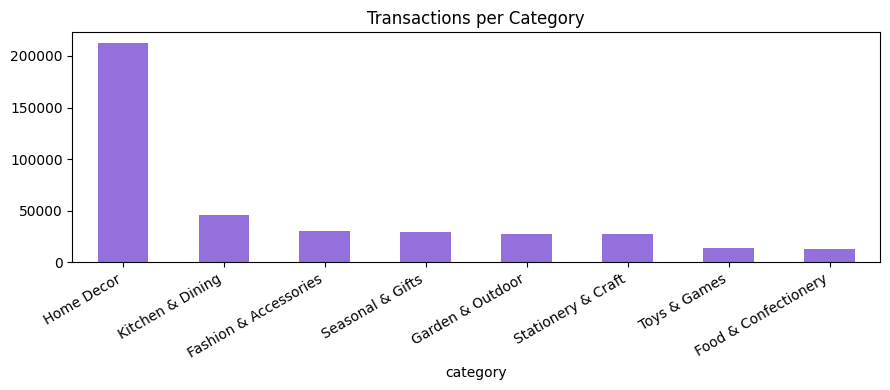

In [61]:
# plot category distribution
cat_counts = df['category'].value_counts()
plt.figure(figsize=(9, 4))
cat_counts.plot(kind='bar', color='mediumpurple')
plt.title('Transactions per Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [62]:
# save product-to-category lookup
mapping = df[['StockCode','Description','category']].drop_duplicates('StockCode').sort_values('StockCode')
mapping.to_csv('data/online+retail/product_categories.csv', index=False)
print('Saved product_categories.csv -', len(mapping), 'products')


Saved product_categories.csv - 3665 products


In [63]:
# customer-level features
REF_DATE = pd.Timestamp('2011-12-09')

def get_segment(n_invoices):
    if n_invoices <= 2:
        return 'New'
    if n_invoices <= 10:
        return 'Occasional'
    return 'Frequent'

def get_price_range(avg_value):
    if avg_value < 178.62:
        return 'Low'
    if avg_value < 293.90:
        return 'Mid-Low'
    if avg_value < 430.11:
        return 'Mid-High'
    return 'High'

customer_features = df.groupby('CustomerID').agg(
    avg_order_value      = ('line_total',  'mean'),
    total_invoices       = ('InvoiceNo',   'nunique'),
    recency_days         = ('InvoiceDate', lambda x: (REF_DATE - x.max()).days),
    favourite_category   = ('category',    lambda x: x.mode()[0]),
    purchased_categories = ('category',    lambda x: list(x.unique())),
    n_categories         = ('category',    'nunique'),
).reset_index()

customer_features['customer_segment'] = customer_features['total_invoices'].apply(get_segment)
customer_features['price_range']      = customer_features['avg_order_value'].apply(get_price_range)

print('Customer segments:')
print(customer_features['customer_segment'].value_counts())
print()
print('Spend tiers:')
print(customer_features['price_range'].value_counts())


Customer segments:
customer_segment
New           2328
Occasional    1673
Frequent       337
Name: count, dtype: int64

Spend tiers:
price_range
Low         4236
Mid-Low       43
High          37
Mid-High      22
Name: count, dtype: int64


In [64]:
# product catalogue with popularity
popularity = (
    df.groupby(['StockCode','Description','category'])['CustomerID']
      .nunique()
      .reset_index(name='popularity_rank')
)
avg_price = df.groupby('StockCode')['UnitPrice'].mean().reset_index(name='avg_price')
product_catalogue = popularity.merge(avg_price, on='StockCode')
product_catalogue = product_catalogue.sort_values('popularity_rank', ascending=False).reset_index(drop=True)

print('Product catalogue:', len(product_catalogue), 'products')
print()
print('Top 10 most popular products:')
print(product_catalogue.head(10)[['Description','category','popularity_rank']].to_string(index=False))


Product catalogue: 3897 products

Top 10 most popular products:
                       Description              category  popularity_rank
          REGENCY CAKESTAND 3 TIER      Kitchen & Dining              881
WHITE HANGING HEART T-LIGHT HOLDER            Home Decor              856
                     PARTY BUNTING            Home Decor              708
     ASSORTED COLOUR BIRD ORNAMENT      Garden & Outdoor              678
 SET OF 3 CAKE TINS PANTRY DESIGN             Home Decor              640
   PACK OF 72 RETROSPOT CAKE CASES      Kitchen & Dining              635
           JUMBO BAG RED RETROSPOT Fashion & Accessories              635
   PAPER CHAIN KIT 50'S CHRISTMAS       Seasonal & Gifts              613
   NATURAL SLATE HEART CHALKBOARD             Home Decor              587
     BAKING SET 9 PIECE RETROSPOT       Garden & Outdoor              581


## 6. Model Training
Two models serve two different roles in the system:
- **ALS** scores specific products within a category (used by `recommend_products`)
- **Two RF classifiers** predict which categories a user will buy from (used by `predict_product`)


### 6a. ALS — Item Similarity
Alternating Least Squares on the full user-item matrix. Item factors are used to build
a product-product similarity matrix for personalized product scoring in `recommend_products()`.


In [65]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares

user_items_sparse = csr_matrix(user_item.values)
print('Sparse matrix shape:', user_items_sparse.shape)
print('Non-zero entries:', user_items_sparse.nnz)

print('\nTraining ALS (factors=50, iterations=50, regularization=1.0)...')
als_model = AlternatingLeastSquares(
    factors=50, iterations=50, regularization=1.0,
    use_gpu=False, random_state=42
)
als_model.fit(user_items_sparse)
print('Done. User factors:', als_model.user_factors.shape,
      '| Item factors:', als_model.item_factors.shape)


Sparse matrix shape: (4338, 3665)
Non-zero entries: 266792

Training ALS (factors=50, iterations=50, regularization=1.0)...


100%|██████████| 50/50 [00:01<00:00, 35.45it/s]

Done. User factors: (4338, 50) | Item factors: (3665, 50)


In [66]:
# item-item cosine similarity from ALS latent factors
item_sim_df = pd.DataFrame(
    cosine_similarity(als_model.item_factors),
    index=user_item.columns, columns=user_item.columns
)
print('Item similarity matrix:', item_sim_df.shape)


Item similarity matrix: (3665, 3665)


In [67]:
# category-category similarity (aggregated from item level)
stock_to_cat = (
    df[['StockCode','category']].drop_duplicates().set_index('StockCode')['category']
)

cat_sim_rows = {}
for cat_a in CATEGORY_KEYWORDS:
    items_a = stock_to_cat[stock_to_cat == cat_a].index.intersection(item_sim_df.index)
    row = {}
    for cat_b in CATEGORY_KEYWORDS:
        items_b = stock_to_cat[stock_to_cat == cat_b].index.intersection(item_sim_df.columns)
        if len(items_a) == 0 or len(items_b) == 0:
            row[cat_b] = 0.0
        else:
            row[cat_b] = float(item_sim_df.loc[items_a, items_b].values.mean())
    cat_sim_rows[cat_a] = row

category_sim_df = pd.DataFrame(cat_sim_rows).T
print('Category similarity matrix:')
print(category_sim_df.round(3))


Category similarity matrix:
                       Home Decor  Kitchen & Dining  Seasonal & Gifts  \
Home Decor                  0.072             0.060             0.049   
Kitchen & Dining            0.060             0.088             0.040   
Seasonal & Gifts            0.049             0.040             0.093   
Toys & Games                0.047             0.046             0.049   
Stationery & Craft          0.065             0.056             0.070   
Fashion & Accessories       0.049             0.040             0.031   
Garden & Outdoor            0.061             0.059             0.049   
Food & Confectionery        0.071             0.081             0.045   

                       Toys & Games  Stationery & Craft  \
Home Decor                    0.047               0.065   
Kitchen & Dining              0.046               0.056   
Seasonal & Gifts              0.049               0.070   
Toys & Games                  0.131               0.078   
Stationery & Craft 

### 6b. Supervised Training Data
One row per customer. Features come from the train period only (no data leakage).
Labels are which categories each customer actually bought in the test period.
Cold-start customers (test-only) get all history features set to zero defaults.


In [68]:
from src.constants import PRODUCT_CATEGORIES

CUTOFF = pd.Timestamp('2011-11-01')
df_train_sup = df[df['InvoiceDate'] < CUTOFF]
df_test_sup  = df[df['InvoiceDate'] >= CUTOFF]

train_cids = set(df_train_sup['CustomerID'].unique())
test_cids  = set(df_test_sup['CustomerID'].unique())
both_cids  = train_cids & test_cids
cold_cids  = test_cids - train_cids   # first purchase ever is in test period

print(f'Train period customers : {len(train_cids)}')
print(f'Test period customers  : {len(test_cids)}')
print(f'Both splits (returning): {len(both_cids)}')
print(f'Test-only (cold-start) : {len(cold_cids)}')


Train period customers : 3974
Test period customers  : 1908
Both splits (returning): 1544
Test-only (cold-start) : 364


In [69]:
# recompute customer stats from TRAIN period ONLY - avoids data leakage
train_stats = df_train_sup.groupby('CustomerID').agg(
    n_purchases        = ('StockCode',   'count'),
    n_categories       = ('category',    'nunique'),
    recency_days       = ('InvoiceDate', lambda x: (CUTOFF - x.max()).days),
    avg_order_value    = ('line_total',  'mean'),
    favourite_category = ('category',    lambda x: x.mode()[0]),
    total_invoices     = ('InvoiceNo',   'nunique'),
)
train_stats['customer_segment'] = train_stats['total_invoices'].apply(get_segment)
train_stats['price_range']      = train_stats['avg_order_value'].apply(get_price_range)

# also get purchase history (list of StockCodes) per customer from train period
train_history = df_train_sup.groupby('CustomerID')['StockCode'].apply(list).to_dict()
print('train_stats shape:', train_stats.shape)
print('Sample row:')
print(train_stats.head(1).T)


train_stats shape: (3974, 8)
Sample row:
CustomerID                     12346
n_purchases                        1
n_categories                       1
recency_days                     286
avg_order_value              77183.6
favourite_category  Kitchen & Dining
total_invoices                     1
customer_segment                 New
price_range                     High


In [70]:
# binary labels: did each customer buy from each category in the test period?
test_cats_per_customer = (
    df_test_sup.groupby('CustomerID')['category']
               .apply(set).to_dict()
)

# only build labels for customers who have test-period purchases
label_customers = list(test_cats_per_customer.keys())
print('Customers with test labels:', len(label_customers))
print('  Returning (both splits):', len([c for c in label_customers if c in both_cids]))
print('  Cold-start (test only) :', len([c for c in label_customers if c in cold_cids]))


Customers with test labels: 1908
  Returning (both splits): 1544
  Cold-start (test only) : 364


In [71]:
# encoding maps for ordinal features
segment_map  = {'New': 0, 'Occasional': 1, 'Frequent': 2}
price_map    = {'Low': 0, 'Mid-Low': 1, 'Mid-High': 2, 'High': 3}

# 9 possible favourite categories (8 product categories + Unknown for cold-start)
all_fav_cats = PRODUCT_CATEGORIES + ['Unknown']
fav_cols     = [f'fav_{c}' for c in all_fav_cats]

print('Context features : segment_enc, price_enc, month (3 features)')
print('History features : n_purchases, n_categories, recency_days, avg_order_value,',
      'segment_enc, price_enc +', len(fav_cols), 'fav_cat one-hot =',
      6 + len(fav_cols), 'features total')
print('Label columns    :', PRODUCT_CATEGORIES)


Context features : segment_enc, price_enc, month (3 features)
History features : n_purchases, n_categories, recency_days, avg_order_value, segment_enc, price_enc + 9 fav_cat one-hot = 15 features total
Label columns    : ['Home Decor', 'Kitchen & Dining', 'Seasonal & Gifts', 'Toys & Games', 'Stationery & Craft', 'Fashion & Accessories', 'Garden & Outdoor', 'Food & Confectionery']


In [72]:
# build training rows for returning customers (have train history + test labels)
rows_returning = []
for cid in both_cids:
    if cid not in test_cats_per_customer:
        continue
    ts    = train_stats.loc[cid]
    fav   = ts['favourite_category'] if ts['favourite_category'] in PRODUCT_CATEGORIES else 'Unknown'
    cats_bought = test_cats_per_customer[cid]

    row = {
        'customer_id'    : cid,
        'n_purchases'    : int(ts['n_purchases']),
        'n_categories'   : int(ts['n_categories']),
        'recency_days'   : int(ts['recency_days']),
        'avg_order_value': float(ts['avg_order_value']),
        'segment_enc'    : segment_map.get(ts['customer_segment'], 0),
        'price_enc'      : price_map.get(ts['price_range'], 0),
        'month'          : 11,   # November -- prediction context at cutoff
    }
    for c in all_fav_cats:
        row[f'fav_{c}'] = 1 if c == fav else 0
    for cat in PRODUCT_CATEGORIES:
        row[cat] = 1 if cat in cats_bought else 0
    rows_returning.append(row)

print('Returning customer rows:', len(rows_returning))


Returning customer rows: 1544


In [73]:
# build training rows for cold-start customers (no train history, only test labels)
rows_cold = []
for cid in cold_cids:
    if cid not in test_cats_per_customer:
        continue
    cats_bought = test_cats_per_customer[cid]

    # all history features are zero/default since they have no prior purchases
    row = {
        'customer_id'    : cid,
        'n_purchases'    : 0,
        'n_categories'   : 0,
        'recency_days'   : 999,
        'avg_order_value': 0.0,
        'segment_enc'    : 0,    # New
        'price_enc'      : 0,    # Low
        'month'          : 11,
    }
    for c in all_fav_cats:
        row[f'fav_{c}'] = 1 if c == 'Unknown' else 0
    for cat in PRODUCT_CATEGORIES:
        row[cat] = 1 if cat in cats_bought else 0
    rows_cold.append(row)

print('Cold-start rows:', len(rows_cold))

# combine
df_train_ml = pd.DataFrame(rows_returning + rows_cold).reset_index(drop=True)
print('Total training rows:', len(df_train_ml))

# check label balance
print('\nPositive label rate per category:')
for cat in PRODUCT_CATEGORIES:
    rate = df_train_ml[cat].mean()
    print(f'  {cat:<28} {rate:.3f}')


Cold-start rows: 364
Total training rows: 1908

Positive label rate per category:
  Home Decor                   0.976
  Kitchen & Dining             0.653
  Seasonal & Gifts             0.693
  Toys & Games                 0.453
  Stationery & Craft           0.543
  Fashion & Accessories        0.505
  Garden & Outdoor             0.633
  Food & Confectionery         0.454


### Train/Test Split

Before training the models, we split the customers into two groups:

- **Training set (80%)** — the models learn from these customers
- **Test set (20%)** — held aside and never shown to the models during training

When we evaluate in Section 6e and Section 7, we only use the **test set customers**.
Because the models have never seen these customers, the results are a fair measure
of how well the system works on people it has not encountered before.

Cold-start customers (those with no purchase history before November) all go into
the training set. There is nothing to evaluate for them at the category level
since we have no pre-November features to build a profile from.


In [74]:
from sklearn.model_selection import train_test_split as split_customers

# returning customers who have both train features and test labels
eligible = sorted(both_cids & set(test_cats_per_customer.keys()))
train_cids_80, test_cids_20 = split_customers(eligible, test_size=0.2, random_state=42)
train_cids_80_set = set(train_cids_80)
test_cids_20_set  = set(test_cids_20)

# training set: 80% returning + ALL cold-start (no test labels to evaluate them with)
df_train_80 = df_train_ml[
    df_train_ml['customer_id'].isin(train_cids_80_set) |
    (df_train_ml['n_purchases'] == 0)
].reset_index(drop=True)

# test set: 20% returning customers — held out entirely
df_test_20 = df_train_ml[
    df_train_ml['customer_id'].isin(test_cids_20_set)
].reset_index(drop=True)

n_cold = (df_train_ml['n_purchases'] == 0).sum()
print(f'Training set : {len(df_train_80)} rows  '
      f'({len(train_cids_80)} returning + {n_cold} cold-start)')
print(f'Test set     : {len(df_test_20)} rows  '
      f'({len(test_cids_20)} returning customers, never seen during training)')


Training set : 1599 rows  (1235 returning + 364 cold-start)
Test set     : 309 rows  (309 returning customers, never seen during training)


### 6c. Model A — Context Model
Features: customer_segment, price_range, current month.
Trained on all customers (including cold-start rows). Works for every user.


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score

context_features = ['segment_enc', 'price_enc', 'month']
label_cols       = list(PRODUCT_CATEGORIES)   # ordered list - index must match estimators_

X_ctx = df_train_80[context_features].values
Y     = df_train_80[label_cols].values

model_context = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=8,
                           class_weight='balanced', random_state=42)
)
model_context.fit(X_ctx, Y)
print('Model A trained. Estimators:', len(model_context.estimators_))
print('Features:', context_features)


Model A trained. Estimators: 8
Features: ['segment_enc', 'price_enc', 'month']


In [76]:
# in-sample check - just to make sure it learned something
# small training set so we expect some overfitting, thats ok
Y_pred_ctx = model_context.predict(X_ctx)
f1_ctx = f1_score(Y, Y_pred_ctx, average='macro', zero_division=0)
print(f'Model A in-sample macro-F1: {f1_ctx:.4f}')
print('(in-sample scores are optimistic - only ~1,844 training rows)')


Model A in-sample macro-F1: 0.4508
(in-sample scores are optimistic - only ~1,844 training rows)


### 6d. Model B — History Model
Features: purchase count, category breadth, recency, spend, favourite category (one-hot).
Trained only on returning customers. Confidence-weighted at inference - new users get 0 weight here.
max_depth=8 controls overfitting on the small training set.


In [77]:
history_features = (
    ['n_purchases', 'n_categories', 'recency_days', 'avg_order_value',
     'segment_enc', 'price_enc']
    + fav_cols   # 9 one-hot columns for favourite_category
)

# train only on returning customers in the 80% training split
df_hist_80 = df_train_80[df_train_80['n_purchases'] > 0].copy()
print('History model training rows:', len(df_hist_80), '(returning customers in training split)')

X_hist = df_hist_80[history_features].values
Y_hist = df_hist_80[label_cols].values

model_history = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=8,
                           class_weight='balanced', random_state=42)
)
model_history.fit(X_hist, Y_hist)
print('Model B trained. Estimators:', len(model_history.estimators_))


History model training rows: 1235 (returning customers in training split)
Model B trained. Estimators: 8


In [78]:
Y_pred_hist = model_history.predict(X_hist)
f1_hist = f1_score(Y_hist, Y_pred_hist, average='macro', zero_division=0)
print(f'Model B in-sample macro-F1: {f1_hist:.4f}')
print('Note: max_depth=8 is intentionally shallow to limit overfitting.')
print('Real generalization is measured in Section 7.')


Model B in-sample macro-F1: 0.8107
Note: max_depth=8 is intentionally shallow to limit overfitting.
Real generalization is measured in Section 7.


### 6e. Classifier Evaluation

We now test the models on the **20% of customers held out during training**.
These customers were never seen by the models, so the results are a genuine
measure of how well the system works on people it has not encountered before.

The features still come from before November 2011 (past behaviour),
and the labels still come from November–December 2011 (future purchases).
Both conditions are satisfied: the customers are unseen, and the labels are from the future.


In [79]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import seaborn as sns

# Build evaluation arrays for the 20% held-out customers only
eval_ctx, eval_hist, eval_y = [], [], []

for cid in sorted(test_cids_20_set):
    if cid not in test_cats_per_customer:
        continue
    ts  = train_stats.loc[cid]
    fav = ts['favourite_category'] if ts['favourite_category'] in PRODUCT_CATEGORIES else 'Unknown'

    eval_ctx.append([
        segment_map.get(ts['customer_segment'], 0),
        price_map.get(ts['price_range'], 0),
        11,
    ])
    fav_ohe = [1 if c == fav else 0 for c in all_fav_cats]
    eval_hist.append([
        int(ts['n_purchases']),
        int(ts['n_categories']),
        int(ts['recency_days']),
        float(ts['avg_order_value']),
        segment_map.get(ts['customer_segment'], 0),
        price_map.get(ts['price_range'], 0),
        *fav_ohe,
    ])
    eval_y.append([1 if cat in test_cats_per_customer[cid] else 0 for cat in label_cols])

X_eval_ctx  = np.array(eval_ctx)
X_eval_hist = np.array(eval_hist)
Y_eval      = np.array(eval_y)

Y_pred_ctx  = model_context.predict(X_eval_ctx)
Y_pred_hist = model_history.predict(X_eval_hist)

print(f'Held-out test customers : {len(Y_eval)}')
print(f'(These customers were not used during model training)')


Held-out test customers : 309
(These customers were not used during model training)


In [80]:
print('Model A — Context (segment, price range, month)')
print('-' * 62)
print(classification_report(Y_eval, Y_pred_ctx, target_names=label_cols, zero_division=0))


Model A — Context (segment, price range, month)
--------------------------------------------------------------
                       precision    recall  f1-score   support

           Home Decor       0.96      0.61      0.75       297
     Kitchen & Dining       0.64      0.60      0.62       197
     Seasonal & Gifts       0.69      0.58      0.63       216
         Toys & Games       0.65      0.16      0.26       136
   Stationery & Craft       0.68      0.14      0.23       165
Fashion & Accessories       0.56      0.65      0.60       156
     Garden & Outdoor       0.74      0.13      0.23       187
 Food & Confectionery       0.46      0.62      0.53       136

            micro avg       0.67      0.46      0.54      1490
            macro avg       0.67      0.44      0.48      1490
         weighted avg       0.70      0.46      0.51      1490
          samples avg       0.40      0.46      0.40      1490



In [81]:
print('Model B — History (purchase count, recency, spend, favourite category)')
print('-' * 62)
print(classification_report(Y_eval, Y_pred_hist, target_names=label_cols, zero_division=0))


Model B — History (purchase count, recency, spend, favourite category)
--------------------------------------------------------------
                       precision    recall  f1-score   support

           Home Decor       0.96      1.00      0.98       297
     Kitchen & Dining       0.79      0.64      0.71       197
     Seasonal & Gifts       0.82      0.70      0.75       216
         Toys & Games       0.62      0.60      0.61       136
   Stationery & Craft       0.69      0.64      0.67       165
Fashion & Accessories       0.69      0.67      0.68       156
     Garden & Outdoor       0.69      0.71      0.70       187
 Food & Confectionery       0.61      0.62      0.62       136

            micro avg       0.76      0.73      0.74      1490
            macro avg       0.73      0.70      0.71      1490
         weighted avg       0.76      0.73      0.74      1490
          samples avg       0.80      0.69      0.67      1490



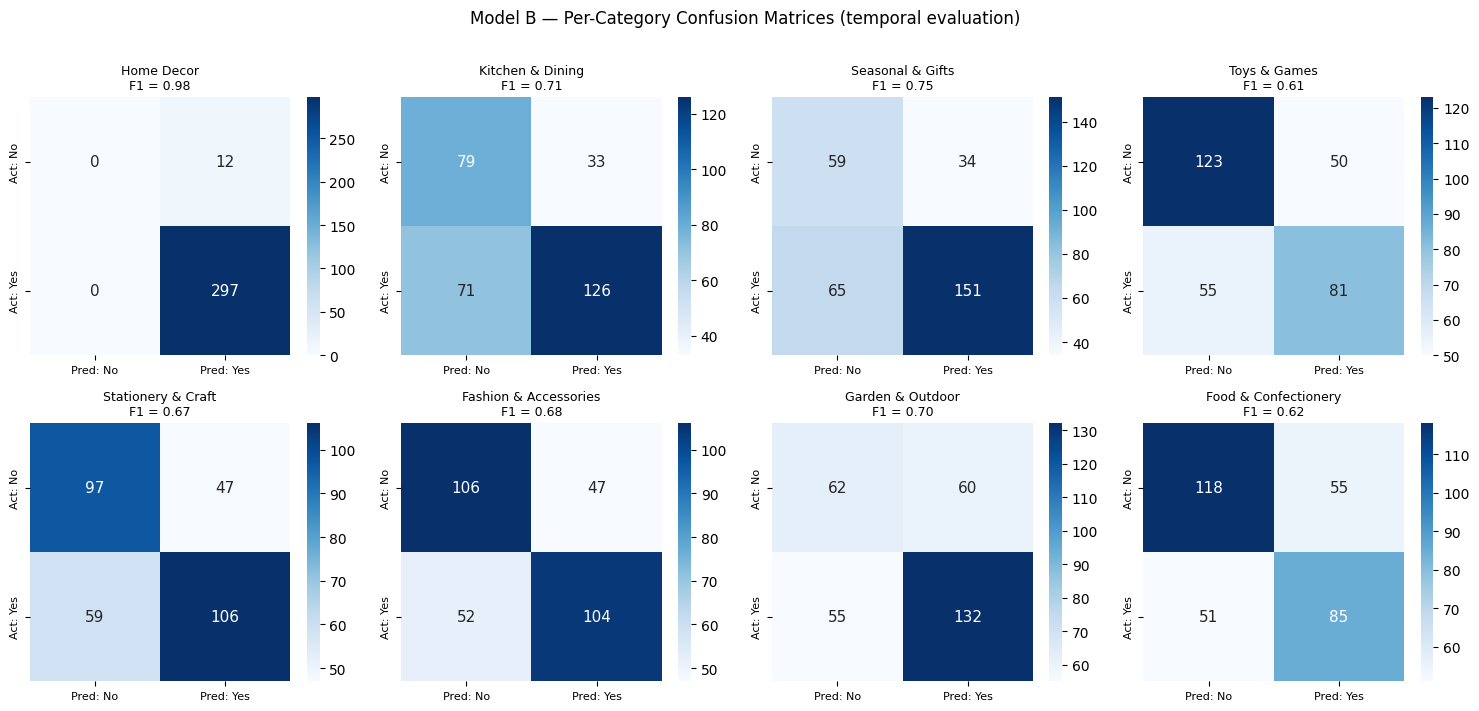

In [82]:
# Confusion matrix per category — Model B
mcm = multilabel_confusion_matrix(Y_eval, Y_pred_hist)

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, (cat, cm) in enumerate(zip(label_cols, mcm)):
    ax = axes[i // 4][i % 4]
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Act: No',  'Act: Yes'],
                annot_kws={'size': 11})
    f1 = 2 * tp / (2 * tp + fp + fn + 1e-9)
    ax.set_title(f'{cat}\nF1 = {f1:.2f}', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Model B — Per-Category Confusion Matrices (temporal evaluation)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 6f. Feature Importance — What Drives the Predictions?

Random Forest models tell us how much each input feature contributed to the predictions.
A higher bar means the model relied on that feature more when deciding which category
a customer is likely to buy from next.

**Model A** only has 3 features — customer segment, price range, and month — so each one
carries more weight. This model is used for customers we know nothing about yet.

**Model B** has 15 features built from purchase history. The chart below shows which
of those features the model found most useful. The `favourite_category` bar combines
all 9 one-hot columns that encode which category the customer buys from most.


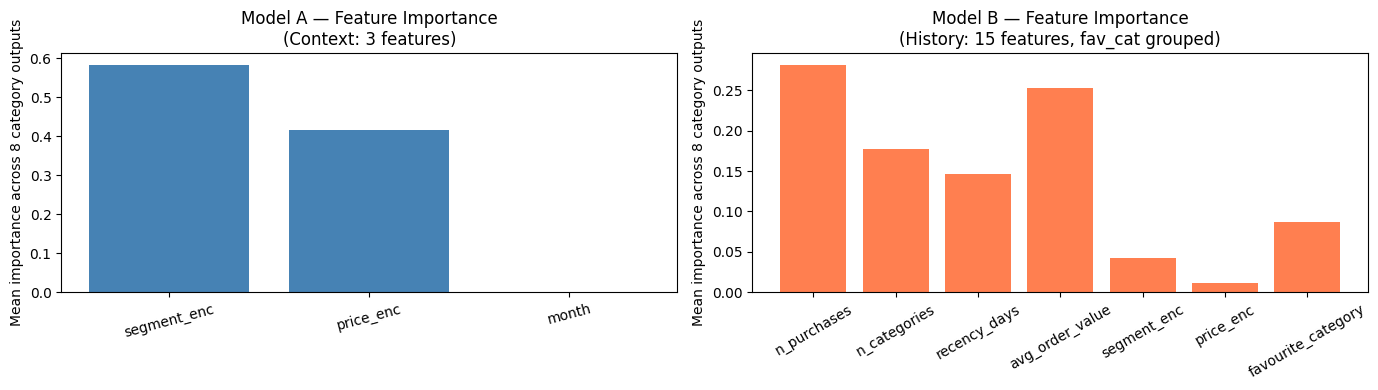

In [83]:
imp_ctx  = np.mean([est.feature_importances_ for est in model_context.estimators_], axis=0)
imp_hist = np.mean([est.feature_importances_ for est in model_history.estimators_], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(context_features, imp_ctx, color='steelblue')
axes[0].set_title('Model A — Feature Importance\n(Context: 3 features)')
axes[0].set_ylabel('Mean importance across 8 category outputs')
axes[0].tick_params(axis='x', rotation=15)

base_feats = ['n_purchases', 'n_categories', 'recency_days', 'avg_order_value',
              'segment_enc', 'price_enc']
fav_imp    = imp_hist[6:].sum()
hist_names = base_feats + ['favourite_category']
hist_imps  = list(imp_hist[:6]) + [fav_imp]

axes[1].bar(hist_names, hist_imps, color='coral')
axes[1].set_title('Model B — Feature Importance\n(History: 15 features, fav_cat grouped)')
axes[1].set_ylabel('Mean importance across 8 category outputs')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### Helper Functions — predict_product()
Defined here so the Section 7 evaluation can call them directly.


In [84]:
def extract_context_features(user_profile):
    """3 features always available from user_profile."""
    return [[
        segment_map.get(user_profile['customer_segment'], 0),
        price_map.get(user_profile['price_range'], 0),
        pd.Timestamp.now().month
    ]]


def extract_history_features(user_profile):
    """15 features - uses purchase history. All default to zero for new users."""
    fav = user_profile.get('favourite_category') or 'Unknown'
    if fav not in all_fav_cats:
        fav = 'Unknown'
    fav_ohe = [1 if c == fav else 0 for c in all_fav_cats]
    return [[
        len(user_profile['purchase_history']),
        len(user_profile.get('purchased_categories', [])),
        user_profile.get('recency_days', 999),
        user_profile.get('avg_order_value', 0.0),
        segment_map.get(user_profile['customer_segment'], 0),
        price_map.get(user_profile['price_range'], 0),
        *fav_ohe
    ]]


def predict_product(user_profile, candidates=None):
    """
    Score candidate categories for this user.
    Works for ALL users including cold-start (no purchase history).

    Confidence blend:
      new user (n=0)    -> 100% context model
      n=5 purchases     -> 17% context + 83% history
      n=10+ purchases   -> ~9% context + ~91% history

    Returns: list[tuple[str, float]] sorted descending by score.
    """
    cats       = candidates or PRODUCT_CATEGORIES
    n_hist     = len(user_profile['purchase_history'])
    confidence = 1.0 - 1.0 / (1.0 + n_hist)

    # Model A: context scores (always computed)
    X_ctx      = extract_context_features(user_profile)
    ctx_scores = np.array([
        est.predict_proba(X_ctx)[0][1] if len(est.classes_) > 1 else 0.0
        for est in model_context.estimators_
    ])

    # Model B: history scores (only meaningful for returning users)
    if n_hist > 0:
        X_hist      = extract_history_features(user_profile)
        hist_scores = np.array([
            est.predict_proba(X_hist)[0][1] if len(est.classes_) > 1 else 0.0
            for est in model_history.estimators_
        ])
    else:
        hist_scores = np.zeros(len(PRODUCT_CATEGORIES))

    # blend by confidence
    blended = (1.0 - confidence) * ctx_scores + confidence * hist_scores

    # filter to requested candidates, return sorted
    scores = {cat: float(blended[i])
              for i, cat in enumerate(PRODUCT_CATEGORIES) if cat in cats}
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


## 7. Recommendation Evaluation

Section 6e checked whether the models correctly classify which categories a customer
will buy from. This section asks a different question: **does the full recommendation
pipeline suggest things the customer actually wants to buy?**

The metric used is **Hit Rate@K (HR@K)**. It works like this:

> For each customer, the system produces a ranked list of K recommendations.
> If at least one of those K items matches something the customer actually bought,
> that is counted as a **hit**. HR@K is the fraction of customers who got at least one hit.

A higher HR@K means more customers received at least one useful recommendation.
K=1 is the strictest test (the single top recommendation must be correct).
K=10 is more lenient.

Both evaluations below use the same time split from Section 6b:
the model is tested on purchases from **November and December 2011**,
which were never used during training.


### 7a. Category Hit Rate@3 

The system recommends 3 product categories for each customer.
This test checks: **was at least one of those 3 categories something the customer
actually bought in November or December?**

We compare two approaches:
- **RF Blend** — the model built in this notebook (Models A + B combined)
- **Popularity** — always recommends the 3 most bought categories site-wide (the simplest possible baseline)

A good model should clearly beat the popularity baseline.


In [85]:
# popularity baseline: the 3 most-bought categories in the training period
cat_popularity  = (
    df_train_sup.groupby('category')['CustomerID']
                .nunique().sort_values(ascending=False)
)
pop_cat_ranking = cat_popularity.index.tolist()

hits_blend = 0
hits_pop   = 0
total_eval = 0

for cid in test_cids_20_set:
    if cid not in test_cats_per_customer:
        continue
    actual_cats = test_cats_per_customer[cid]
    if not actual_cats:
        continue

    ts      = train_stats.loc[cid]
    history = train_history.get(cid, [])
    fav     = ts['favourite_category'] if ts['favourite_category'] in PRODUCT_CATEGORIES else None
    profile = {
        'customer_id'          : cid,
        'purchase_history'     : list(set(history)),
        'avg_order_value'      : float(ts['avg_order_value']),
        'total_invoices'       : int(ts['total_invoices']),
        'recency_days'         : int(ts['recency_days']),
        'price_range'          : ts['price_range'],
        'customer_segment'     : ts['customer_segment'],
        'favourite_category'   : fav,
        'purchased_categories' : list(df_train_sup[df_train_sup['CustomerID']==cid]['category'].unique()),
    }

    if any(c in actual_cats for c in [c for c, _ in predict_product(profile)[:3]]):
        hits_blend += 1
    if any(c in actual_cats for c in pop_cat_ranking[:3]):
        hits_pop += 1

    total_eval += 1

print(f'Category HR@3 — {total_eval} returning customers tested')
print(f'(Tested on November-December 2011 purchases)')
print()
print(f'{"Approach":<28} {"HR@3":>8}  Meaning')
print('-' * 60)
print(f'{"RF Blend (this model)":<28} {hits_blend/total_eval:>8.4f}  top-3 categories included a correct one')
print(f'{"Popularity baseline":<28} {hits_pop/total_eval:>8.4f}  just recommend the 3 most popular categories')
print()
lift = (hits_blend - hits_pop) / total_eval
print(f'Improvement over popularity: +{lift:.4f} ({lift/( hits_pop/total_eval)*100:.1f}% relative)')


Category HR@3 — 309 returning customers tested
(Tested on November-December 2011 purchases)

Approach                         HR@3  Meaning
------------------------------------------------------------
RF Blend (this model)          0.9806  top-3 categories included a correct one
Popularity baseline            0.9676  just recommend the 3 most popular categories

Improvement over popularity: +0.0129 (1.3% relative)


### 7b. Product Hit Rate@K — recommend_products()

This goes one level deeper. Instead of checking categories, it checks **specific products**.

The system recommends K individual products for each customer based on ALS item similarity.
The question is: **was any one of those K products something the customer actually bought
in November or December?**

We use the ALS item-similarity matrix built in Section 6a. For each returning customer,
we use only their pre-November purchases to generate recommendations, then check
against their actual November–December purchases. The popularity baseline recommends
the K most globally purchased products (excluding ones the customer already owns).

K is tested at 1, 3, 5, and 10 so we can see how the hit rate improves as we show
the customer more recommendations.


In [86]:
# Use numpy indexing for speed — avoids pandas .loc overhead on the large matrix
items_list  = list(item_sim_df.columns)
item_to_idx = {sc: i for i, sc in enumerate(items_list)}
sim_np      = item_sim_df.values   # (n_items, n_items) numpy array

# global popularity ranking from training period
pop_items = (
    df_train_sup.groupby('StockCode')['CustomerID']
                .nunique().sort_values(ascending=False).index.tolist()
)
pop_idxs = [item_to_idx[sc] for sc in pop_items if sc in item_to_idx]

K_values = [1, 3, 5, 10]
hits = {'ALS': {k: 0 for k in K_values}, 'Popularity': {k: 0 for k in K_values}}
total_prod = 0

for cid in test_cids_20_set:
    seed    = train_history.get(cid, [])   # purchases before cutoff
    actual  = df_test_sup[df_test_sup['CustomerID'] == cid]['StockCode'].unique().tolist()
    if not seed or not actual:
        continue

    seed_idxs   = [item_to_idx[sc] for sc in seed   if sc in item_to_idx]
    actual_idxs = {item_to_idx[sc] for sc in actual if sc in item_to_idx}
    if not seed_idxs or not actual_idxs:
        continue

    # ALS: score every item by average similarity to seed items, exclude already owned
    scores = sim_np[:, seed_idxs].mean(axis=1)
    scores[seed_idxs] = -np.inf
    top_als = np.argsort(-scores)[:max(K_values)]

    # Popularity: top global items the customer hasn't bought yet
    seed_set = set(seed_idxs)
    top_pop  = [p for p in pop_idxs if p not in seed_set][:max(K_values)]

    for k in K_values:
        if set(top_als[:k]) & actual_idxs:
            hits['ALS'][k] += 1
        if set(top_pop[:k]) & actual_idxs:
            hits['Popularity'][k] += 1

    total_prod += 1

print(f'Product HR@K — {total_prod} returning customers tested')
print(f'(Seed: pre-November purchases  |  Target: November-December purchases)')
print()
print(f'{"Approach":<18} {"HR@1":>6} {"HR@3":>6} {"HR@5":>6} {"HR@10":>6}')
print('-' * 46)
for model in ['ALS', 'Popularity']:
    row = [f'{hits[model][k]/total_prod:.4f}' for k in K_values]
    print(f'{model:<18} {row[0]:>6} {row[1]:>6} {row[2]:>6} {row[3]:>6}')


Product HR@K — 309 returning customers tested
(Seed: pre-November purchases  |  Target: November-December purchases)

Approach             HR@1   HR@3   HR@5  HR@10
----------------------------------------------
ALS                0.1424 0.2589 0.3204 0.4207
Popularity         0.0388 0.0809 0.1521 0.2589


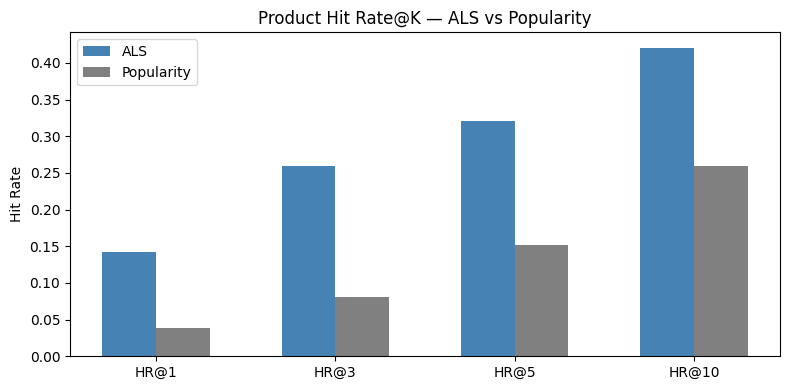

In [87]:
K_labels = ['HR@1', 'HR@3', 'HR@5', 'HR@10']
als_vals = [hits['ALS'][k]        / total_prod for k in K_values]
pop_vals = [hits['Popularity'][k]  / total_prod for k in K_values]
x, w = range(len(K_labels)), 0.3

plt.figure(figsize=(8, 4))
plt.bar([i - w/2 for i in x], als_vals, w, label='ALS', color='steelblue')
plt.bar([i + w/2 for i in x], pop_vals, w, label='Popularity', color='gray')
plt.xticks(list(x), K_labels)
plt.ylabel('Hit Rate')
plt.title('Product Hit Rate@K — ALS vs Popularity')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Save Artefacts


In [88]:
os.makedirs('models', exist_ok=True)

# ALS artefacts (for recommend_products)
pickle.dump(als_model,         open('models/als_model.pkl',          'wb'))
pickle.dump(item_sim_df,       open('models/similarity_matrix.pkl',  'wb'))
pickle.dump(category_sim_df,   open('models/category_similarity.pkl','wb'))

# supervised RF models (for predict_product)
pickle.dump(model_context,     open('models/model_context.pkl',      'wb'))
pickle.dump(model_history,     open('models/model_history.pkl',      'wb'))

# shared artefacts
pickle.dump(product_catalogue, open('models/product_catalogue.pkl',  'wb'))
pickle.dump(customer_features, open('models/customer_features.pkl',  'wb'))

from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder().fit(PRODUCT_CATEGORIES)
pickle.dump(enc, open('models/encoder_category.pkl', 'wb'))

print('Saved:')
for fname in ['als_model.pkl', 'similarity_matrix.pkl', 'category_similarity.pkl',
              'model_context.pkl', 'model_history.pkl',
              'product_catalogue.pkl', 'customer_features.pkl', 'encoder_category.pkl']:
    size = os.path.getsize(f'models/{fname}') / 1e6
    print(f'  {fname:<42} {size:.2f} MB')


Saved:
  als_model.pkl                              1.60 MB
  similarity_matrix.pkl                      53.76 MB
  category_similarity.pkl                    0.00 MB
  model_context.pkl                          1.04 MB
  model_history.pkl                          8.45 MB
  product_catalogue.pkl                      0.23 MB
  customer_features.pkl                      0.29 MB
  encoder_category.pkl                       0.00 MB


## 9. Inference Functions
Copy of the functions defined in Section 6. Reload artefacts here so this section
can be run independently by Member 4.


In [89]:
# reload all artefacts
item_sim_df       = pickle.load(open('models/similarity_matrix.pkl',  'rb'))
product_catalogue = pickle.load(open('models/product_catalogue.pkl',  'rb'))
model_context     = pickle.load(open('models/model_context.pkl',      'rb'))
model_history     = pickle.load(open('models/model_history.pkl',      'rb'))
from src.constants import PRODUCT_CATEGORIES
print('Artefacts loaded.')


Artefacts loaded.


In [90]:
# encoding constants (must match what was used during training)
segment_map  = {'New': 0, 'Occasional': 1, 'Frequent': 2}
price_map    = {'Low': 0, 'Mid-Low': 1, 'Mid-High': 2, 'High': 3}
all_fav_cats = PRODUCT_CATEGORIES + ['Unknown']


In [91]:
def extract_context_features(user_profile):
    """3 features always available from user_profile."""
    return [[
        segment_map.get(user_profile['customer_segment'], 0),
        price_map.get(user_profile['price_range'], 0),
        pd.Timestamp.now().month
    ]]


def extract_history_features(user_profile):
    """15 features from purchase history. Defaults to zero for new users."""
    fav = user_profile.get('favourite_category') or 'Unknown'
    if fav not in all_fav_cats:
        fav = 'Unknown'
    fav_ohe = [1 if c == fav else 0 for c in all_fav_cats]
    return [[
        len(user_profile['purchase_history']),
        len(user_profile.get('purchased_categories', [])),
        user_profile.get('recency_days', 999),
        user_profile.get('avg_order_value', 0.0),
        segment_map.get(user_profile['customer_segment'], 0),
        price_map.get(user_profile['price_range'], 0),
        *fav_ohe
    ]]


def predict_product(user_profile, candidates=None):
    """
    Score candidate categories for a user.
    Works for ALL users including cold-start (no purchase history).

    Parameters
    ----------
    user_profile : dict  from build_user_profile()
    candidates   : list  subset of PRODUCT_CATEGORIES (default: all)

    Returns
    -------
    list[tuple[str, float]]  [(category, score), ...] sorted descending
    """
    cats       = candidates or PRODUCT_CATEGORIES
    n_hist     = len(user_profile['purchase_history'])
    confidence = 1.0 - 1.0 / (1.0 + n_hist)

    X_ctx      = extract_context_features(user_profile)
    ctx_scores = np.array([
        est.predict_proba(X_ctx)[0][1] if len(est.classes_) > 1 else 0.0
        for est in model_context.estimators_
    ])

    if n_hist > 0:
        X_hist      = extract_history_features(user_profile)
        hist_scores = np.array([
            est.predict_proba(X_hist)[0][1] if len(est.classes_) > 1 else 0.0
            for est in model_history.estimators_
        ])
    else:
        hist_scores = np.zeros(len(PRODUCT_CATEGORIES))

    blended = (1.0 - confidence) * ctx_scores + confidence * hist_scores
    scores  = {cat: float(blended[i])
               for i, cat in enumerate(PRODUCT_CATEGORIES) if cat in cats}
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


In [92]:
def recommend_products(user_profile, category, top_n=3):
    """
    Recommend specific products within a category using ALS item similarity.
    Falls back to popularity if user has no purchase history.

    Parameters
    ----------
    user_profile : dict  from build_user_profile()
    category     : str   one of PRODUCT_CATEGORIES
    top_n        : int   number of products to return (default 3)

    Returns
    -------
    list[dict]  [{category, product, price, score}, ...]
    """
    bought       = user_profile['purchase_history']
    valid_bought = [sc for sc in bought if sc in item_sim_df.columns]

    cat_items = product_catalogue[product_catalogue['category'] == category].copy()
    unowned   = cat_items[~cat_items['StockCode'].isin(bought)]

    if not valid_bought or unowned.empty:
        top = unowned.nlargest(top_n, 'popularity_rank')
        return [{'category': category, 'product': row['Description'],
                 'price': round(float(row['avg_price']), 2), 'score': 0.0}
                for _, row in top.iterrows()]

    valid_unowned = unowned[unowned['StockCode'].isin(item_sim_df.index)].copy()
    if valid_unowned.empty:
        top = unowned.nlargest(top_n, 'popularity_rank')
        return [{'category': category, 'product': row['Description'],
                 'price': round(float(row['avg_price']), 2), 'score': 0.0}
                for _, row in top.iterrows()]

    valid_unowned['score'] = (
        item_sim_df.loc[valid_unowned['StockCode'], valid_bought]
                   .mean(axis=1).values
    )
    top = valid_unowned.nlargest(top_n, 'score')
    return [{'category': category,
             'product':  row['Description'],
             'price':    round(float(row['avg_price']), 2),
             'score':    round(float(row['score']), 4)}
            for _, row in top.iterrows()]


## 10. Demo

We run all 5 sample profiles through the system to show the full output.
The last part of this section traces through exactly how one recommendation is built,
step by step, so the reasoning is visible.


In [93]:
from src.constants import SAMPLE_PROFILES

for name, profile in SAMPLE_PROFILES.items():
    print('=' * 58)
    print('Profile:', name)
    print('  Segment     :', profile['customer_segment'])
    print('  Price range :', profile['price_range'])
    print('  History     :', len(profile['purchase_history']), 'items')

    n = len(profile['purchase_history'])
    conf = 1.0 - 1.0 / (1.0 + n)
    print(f'  Confidence  : {conf:.2f} ({"context only" if n == 0 else f"blend ({conf:.0%} history)"})')

    top_cats = predict_product(profile)[:3]
    print('  Top 3 categories:')
    for cat, score in top_cats:
        print(f'    {cat:<28} score={score:.4f}')

    print('  Recommended products (3 per category):')
    for cat, score in top_cats:
        recs = recommend_products(profile, category=cat, top_n=3)
        for r in recs:
            score_label = f'{r["score"]:.4f}' if r['score'] > 0 else 'popular'
            print(f'    [{r["category"][:20]:<20}] {r["product"][:40]:<40} £{r["price"]:>5.2f}  {score_label}')


Profile: gift_buyer
  Segment     : Occasional
  Price range : Low
  History     : 5 items
  Confidence  : 0.83 (blend (83% history))
  Top 3 categories:
    Home Decor                   score=0.6256
    Seasonal & Gifts             score=0.5409
    Garden & Outdoor             score=0.3222
  Recommended products (3 per category):
    [Home Decor          ] PINK BABY BUNTING                        £ 2.97  0.5555
    [Home Decor          ] PARTY BUNTING                            £ 4.88  0.5206
    [Home Decor          ] VINTAGE UNION JACK BUNTING               £ 8.51  0.4651
    [Seasonal & Gifts    ] WOODEN HAPPY BIRTHDAY GARLAND            £ 2.97  0.3700
    [Seasonal & Gifts    ] GARLAND WOODEN HAPPY EASTER              £ 1.25  0.2737
    [Seasonal & Gifts    ] VINTAGE CHRISTMAS STOCKING               £ 2.55  0.2649
    [Garden & Outdoor    ] YELLOW FELT HANGING HEART W FLOWER       £ 0.85  0.2557
    [Garden & Outdoor    ] PINK FELT HANGING HEART W FLOWER         £ 0.85  0.2432
   

### How a Recommendation is Made — Step by Step

This trace walks through exactly what happens inside the system for one customer
(`home_decorator`). Each step is printed so the reasoning is fully visible.

1. The customer's past purchases are used to build two sets of features
2. Both models score all 8 categories independently
3. The scores are blended — customers with more history lean more on Model B
4. The top category's products are scored using item similarity from ALS


In [94]:
profile = SAMPLE_PROFILES['home_decorator']
n_hist     = len(profile['purchase_history'])
confidence = 1.0 - 1.0 / (1.0 + n_hist)

print('─' * 60)
print('STEP-BY-STEP TRACE — home_decorator')
print('─' * 60)
print(f'Purchase history : {n_hist} items')
print(f'Confidence       : {confidence:.2f}  →  Model A weight {1-confidence:.0%}, Model B weight {confidence:.0%}')

# Step 1: Context features
x_ctx = extract_context_features(profile)[0]
print(f'\nStep 1 — Context features (Model A input)')
for name, val in zip(context_features, x_ctx):
    print(f'  {name:<20}: {val}')

# Step 2: History features
x_hist = extract_history_features(profile)[0]
print(f'\nStep 2 — History features (Model B input, first 6 shown)')
for name, val in zip(history_features[:6], x_hist[:6]):
    print(f'  {name:<20}: {val}')
print(f'  favourite_category  : {profile["favourite_category"]} (one-hot encoded)')

# Step 3: Model A probabilities
ctx_scores = np.array([
    est.predict_proba([x_ctx])[0][1] if len(est.classes_) > 1 else 0.0
    for est in model_context.estimators_
])
print(f'\nStep 3 — Model A: probability of buying each category')
for cat, s in zip(label_cols, ctx_scores):
    print(f'  {cat:<28}: {s:.4f}')

# Step 4: Model B probabilities
hist_scores = np.array([
    est.predict_proba([x_hist])[0][1] if len(est.classes_) > 1 else 0.0
    for est in model_history.estimators_
])
print(f'\nStep 4 — Model B: probability of buying each category')
for cat, s in zip(label_cols, hist_scores):
    print(f'  {cat:<28}: {s:.4f}')

# Step 5: Blended final scores
blended = (1.0 - confidence) * ctx_scores + confidence * hist_scores
ranked  = sorted(zip(label_cols, blended), key=lambda x: x[1], reverse=True)
print(f'\nStep 5 — Blended score ({1-confidence:.0%} × Model A + {confidence:.0%} × Model B)')
for cat, s in ranked:
    print(f'  {cat:<28}: {s:.4f}')

# Step 6: Products for the top category
top_cat      = ranked[0][0]
top_products = recommend_products(profile, category=top_cat, top_n=3)
print(f'\nStep 6 — Top 3 products in "{top_cat}" via ALS item similarity')
print(f'  (Scored against items the customer already owns: {profile["purchase_history"]})')
for p in top_products:
    print(f'  {p["product"][:40]:<40} £{p["price"]:>5.2f}  similarity={p["score"]:.4f}')


────────────────────────────────────────────────────────────
STEP-BY-STEP TRACE — home_decorator
────────────────────────────────────────────────────────────
Purchase history : 4 items
Confidence       : 0.80  →  Model A weight 20%, Model B weight 80%

Step 1 — Context features (Model A input)
  segment_enc         : 2
  price_enc           : 0
  month               : 6

Step 2 — History features (Model B input, first 6 shown)
  n_purchases         : 4
  n_categories        : 2
  recency_days        : 20
  avg_order_value     : 80.31
  segment_enc         : 2
  price_enc           : 0
  favourite_category  : Home Decor (one-hot encoded)

Step 3 — Model A: probability of buying each category
  Home Decor                  : 0.7048
  Kitchen & Dining            : 0.6719
  Seasonal & Gifts            : 0.6107
  Toys & Games                : 0.6297
  Stationery & Craft          : 0.6308
  Fashion & Accessories       : 0.6460
  Garden & Outdoor            : 0.6609
  Food & Confectionery     